# **AgriSense TN — IoT Sensor Data Simulation**

**About the dataset**

Name: AgriSense TN — IoT Crop Field Sensor Dataset

Type: Simulated IoT time-series data  

Region: Tamil Nadu, India

Period: June – November 2024

Frequency: Hourly readings

Total Records: 13,107 rows × 11 columns

Real-time IoT sensor data from Tamil Nadu agricultural fields is not publicly available. This dataset was synthetically generated based on:


**IMD (India Meteorological Department) seasonal climate patterns for Tamil Nadu**

**ICAR agronomic guidelines for soil and crop requirements**

**Realistic sensor noise and anomaly injection to mimic real field conditions**

In [69]:
"""
AgriSense TN — IoT Sensor Data Simulation v2
=============================================
Fix: Multi-feature irrigation label + 8% noise
     Prevents 100% accuracy in ML models
Output: agrisense_sensor_data.csv
"""

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

START_DATE     = datetime(2024, 6, 1)
END_DATE       = datetime(2024, 11, 30)
INTERVAL_HOURS = 1

DISTRICT_CROP = {
    "Thanjavur":  "Rice",
    "Erode":      "Turmeric",
    "Coimbatore": "Tomato"
}

CROP_BASE = {
    "Rice":     {"soil_moisture": 70, "soil_temp": 28, "air_temp": 30, "humidity": 78, "rainfall": 8,  "nitrogen": 180},
    "Turmeric": {"soil_moisture": 50, "soil_temp": 26, "air_temp": 28, "humidity": 65, "rainfall": 5,  "nitrogen": 140},
    "Tomato":   {"soil_moisture": 42, "soil_temp": 24, "air_temp": 27, "humidity": 60, "rainfall": 3,  "nitrogen": 120},
}

SEASONAL = {
    6:  (1.20, 0.95, 1.15, 1.80),
    7:  (1.30, 0.90, 1.20, 2.00),
    8:  (1.25, 0.92, 1.18, 1.90),
    9:  (1.15, 0.95, 1.10, 1.50),
    10: (1.05, 1.00, 1.05, 1.20),
    11: (0.90, 1.05, 0.95, 0.80),
}

def add_noise(value, std=2.0):
    return round(value + np.random.normal(0, std), 2)

# ── FIXED: Multi-feature label with noise ──
def get_irrigation_label(soil_moisture, humidity, rainfall, air_temp, crop):
    thresholds = {
        "Rice":     (48, 68),
        "Turmeric": (33, 53),
        "Tomato":   (28, 48),
    }
    low, high = thresholds[crop]

    # Weighted stress score from multiple sensors
    moisture_stress = max(0, (low - soil_moisture) / max(low, 1))
    humidity_stress = max(0, (55 - humidity) / 55)
    rainfall_relief = min(1, rainfall / 8.0)
    temp_stress     = max(0, (air_temp - 35) / 15)

    stress_score = (
        0.55 * moisture_stress +
        0.20 * humidity_stress +
        0.15 * temp_stress -
        0.10 * rainfall_relief
    )

    if soil_moisture < low - 5 or stress_score > 0.45:
        label = "Irrigate Now"
    elif soil_moisture > high + 5 and stress_score < 0.05:
        label = "No Action"
    else:
        label = "Monitor"

    # 4% label noise — real-world uncertainty
    if random.random() < 0.04:
        label = random.choice(["Irrigate Now", "Monitor", "No Action"])

    return label

def maybe_inject_anomaly(row, anomaly_prob=0.04):
    if random.random() < anomaly_prob:
        anomaly_type = random.choice(["drought", "flood", "heat_stress"])
        if anomaly_type == "drought":
            row["soil_moisture"] = round(max(5, row["soil_moisture"] * 0.35), 2)
            row["rainfall_mm"]   = 0.0
            row["anomaly"]       = "Drought Stress"
        elif anomaly_type == "flood":
            row["soil_moisture"] = round(min(100, row["soil_moisture"] * 1.6), 2)
            row["rainfall_mm"]   = round(row["rainfall_mm"] * 3.5, 2)
            row["anomaly"]       = "Flood/Overwatering"
        elif anomaly_type == "heat_stress":
            row["air_temp_c"]  = round(row["air_temp_c"]  + random.uniform(6, 10), 2)
            row["soil_temp_c"] = round(row["soil_temp_c"] + random.uniform(4, 7),  2)
            row["anomaly"]     = "Heat Stress"
    else:
        row["anomaly"] = "Normal"
    return row

def simulate():
    records = []
    timestamps = []
    current = START_DATE
    while current <= END_DATE:
        timestamps.append(current)
        current += timedelta(hours=INTERVAL_HOURS)

    print(f"Generating {len(timestamps)} timestamps × {len(DISTRICT_CROP)} districts...")

    for district, crop in DISTRICT_CROP.items():
        base = CROP_BASE[crop]
        for ts in timestamps:
            sf = SEASONAL.get(ts.month, (1.0, 1.0, 1.0, 1.0))

            soil_moisture = round(min(100, max(0,  add_noise(base["soil_moisture"] * sf[0], 8.0))), 2)
            soil_temp     = round(min(50,  max(10, add_noise(base["soil_temp"]     * sf[1], 1.5))), 2)
            air_temp      = round(min(50,  max(10, add_noise(base["air_temp"]      * sf[1], 1.5))), 2)
            humidity      = round(min(100, max(10, add_noise(base["humidity"]      * sf[2], 4.0))), 2)
            rainfall      = round(max(0,           add_noise(base["rainfall"]      * sf[3], 1.0)),  2)
            nitrogen      = round(max(0,           add_noise(base["nitrogen"],               5.0)), 2)

            row = {
                "timestamp":      ts.strftime("%Y-%m-%d %H:%M:%S"),
                "district":       district,
                "crop":           crop,
                "soil_moisture":  soil_moisture,
                "soil_temp_c":    soil_temp,
                "air_temp_c":     air_temp,
                "humidity_pct":   humidity,
                "rainfall_mm":    rainfall,
                "nitrogen_mg_kg": nitrogen,
                "anomaly":        "Normal",
            }

            row = maybe_inject_anomaly(row)

            # FIXED: pass all sensor values to label function
            row["irrigation_needed"] = get_irrigation_label(
                row["soil_moisture"], row["humidity_pct"],
                row["rainfall_mm"],   row["air_temp_c"], crop
            )
            records.append(row)

    return pd.DataFrame(records)

if __name__ == "__main__":
    df = simulate()
    df.to_csv("agrisense_sensor_data.csv", index=False)
    print(f"\n✅ Dataset saved: agrisense_sensor_data.csv")
    print(f"   Rows    : {len(df):,}")
    print(f"\nIrrigation label distribution:")
    print(df["irrigation_needed"].value_counts())
    print(f"\nAnomaly distribution:")
    print(df["anomaly"].value_counts())

Generating 4369 timestamps × 3 districts...

✅ Dataset saved: agrisense_sensor_data.csv
   Rows    : 13,107

Irrigation label distribution:
irrigation_needed
No Action       6555
Monitor         6148
Irrigate Now     404
Name: count, dtype: int64

Anomaly distribution:
anomaly
Normal                12602
Flood/Overwatering      175
Drought Stress          170
Heat Stress             160
Name: count, dtype: int64


# **Import Neccessary Libraries**

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import lime
import lime.lime_tabular

# **Load the Simulated Dataset**

In [72]:
df = pd.read_csv("agrisense_sensor_data.csv")
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13107 entries, 0 to 13106
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          13107 non-null  object 
 1   district           13107 non-null  object 
 2   crop               13107 non-null  object 
 3   soil_moisture      13107 non-null  float64
 4   soil_temp_c        13107 non-null  float64
 5   air_temp_c         13107 non-null  float64
 6   humidity_pct       13107 non-null  float64
 7   rainfall_mm        13107 non-null  float64
 8   nitrogen_mg_kg     13107 non-null  float64
 9   anomaly            13107 non-null  object 
 10  irrigation_needed  13107 non-null  object 
dtypes: float64(6), object(5)
memory usage: 1.1+ MB
None
       soil_moisture   soil_temp_c    air_temp_c  humidity_pct   rainfall_mm  \
count   13107.000000  13107.000000  13107.000000  13107.000000  13107.000000   
mean       61.570672     25.050322     27.337764  

# **Feature Engineering**

**1.Encode Categorical Variables**

In [73]:
print("\nUnique Target Values:")
print(df['irrigation_needed'].unique())

# Convert text labels into numbers
df['irrigation_needed'] = df['irrigation_needed'].map({
    'No Action':    0,
    'Monitor':      1,
    'Irrigate Now': 2
})

# Remove rows that failed mapping
df = df.dropna(subset=['irrigation_needed'])

# Convert target datatype to integer
df['irrigation_needed'] = df['irrigation_needed'].astype(int)

print("\nMapped Value Counts:")
print(df['irrigation_needed'].value_counts().sort_index())


Unique Target Values:
['Monitor' 'No Action' 'Irrigate Now']

Mapped Value Counts:
irrigation_needed
0    6555
1    6148
2     404
Name: count, dtype: int64


**2.Replace Missing Values using Mean Imputation**

In [74]:
df['rainfall_mm'] = df['rainfall_mm'].fillna(
    df['rainfall_mm'].mean()
)

**3.Feature Generation using Existing Feature Timestamp**

In [75]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month'] = df['timestamp'].dt.month
df['hour'] = df['timestamp'].dt.hour

# **Exploratory Data Analysis**

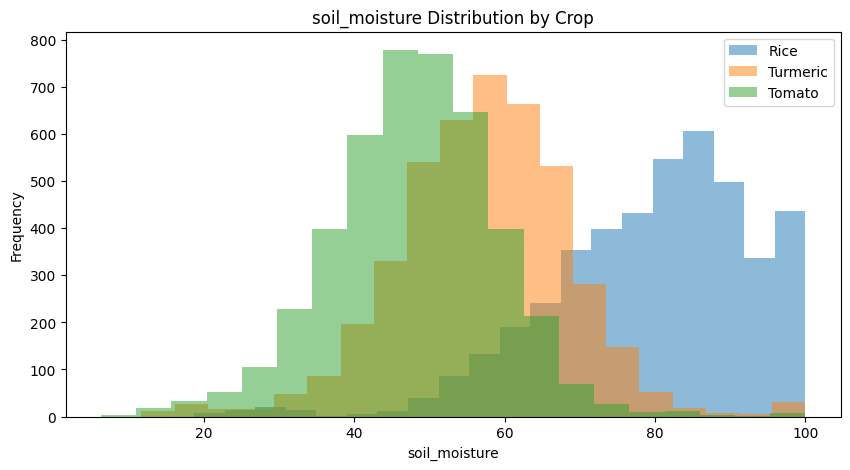

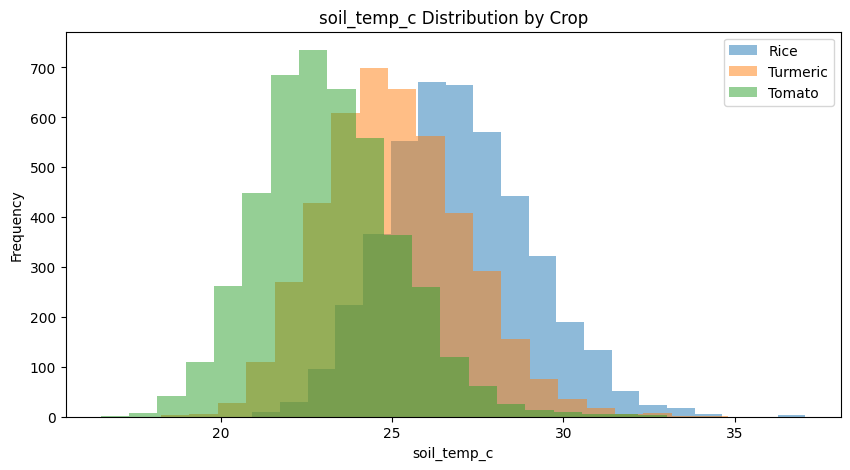

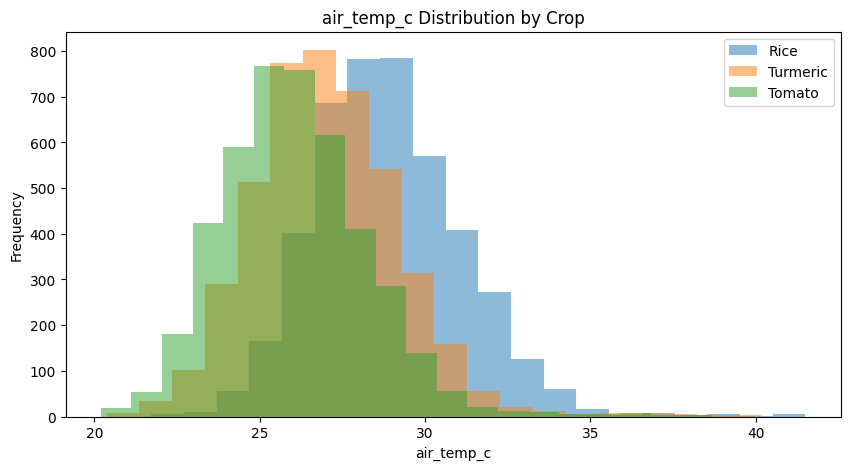

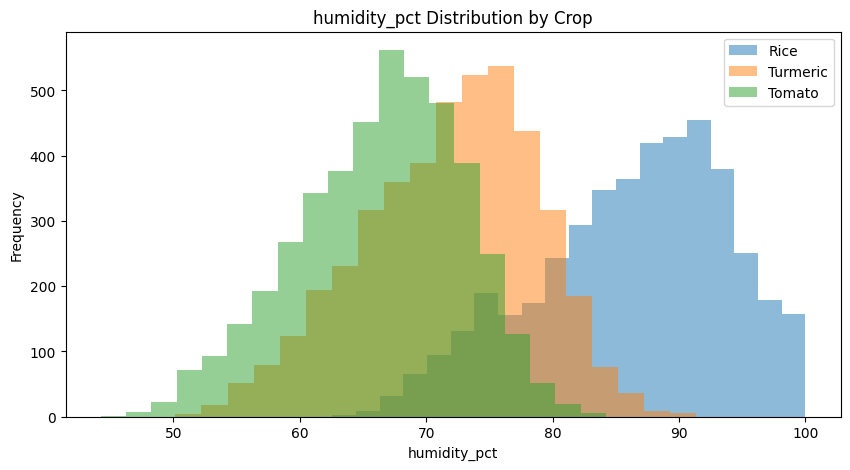

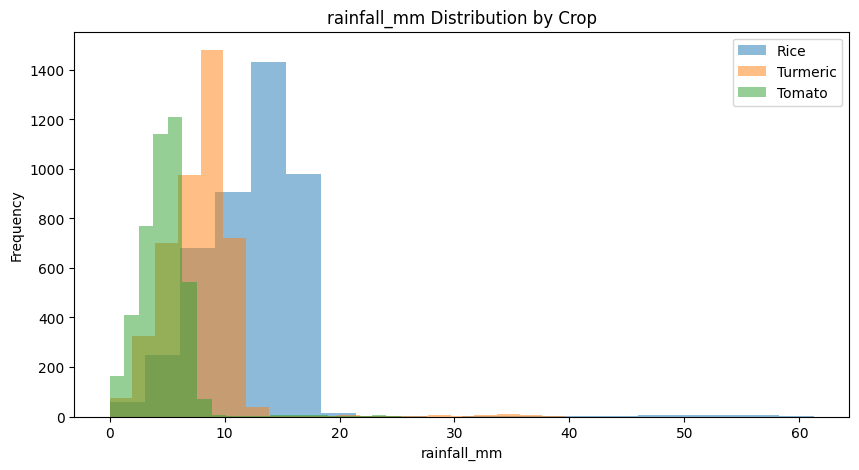

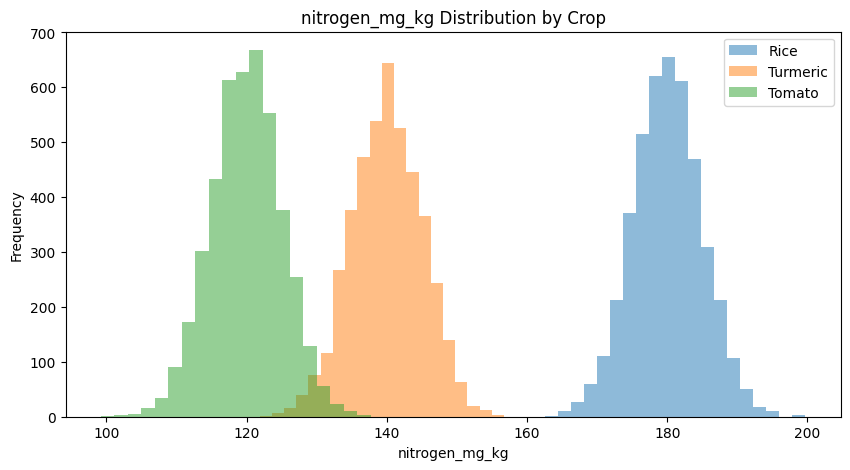

In [76]:
sensors = [
    'soil_moisture',
    'soil_temp_c',
    'air_temp_c',
    'humidity_pct',
    'rainfall_mm',
    'nitrogen_mg_kg'
]
for sensor in sensors:

    plt.figure(figsize=(10,5))

    for crop in df['crop'].unique():

        crop_data = df[df['crop'] == crop]

        plt.hist(
            crop_data[sensor],
            bins=20,
            alpha=0.5,
            label=crop
        )

    plt.title(f'{sensor} Distribution by Crop')
    plt.xlabel(sensor)
    plt.ylabel('Frequency')

    plt.legend()
    plt.show()

**1. soil_moisture**
Rice (Thanjavur) — distribution peaks at 60–85% — consistent with paddy water requirements
Turmeric (Erode) — peaks at 40–60% — moderate moisture loving crop
Tomato (Coimbatore) — peaks at 30–50% — lowest moisture, drought tolerant
**Insight: Clear separation between crops — soil moisture is the strongest differentiator**


**2. soil_temp_c**
All 3 crops show overlapping distributions around 24–32°C
Rice slightly higher — Thanjavur delta region is warmer and more humid
**Insight: Least separating feature — all crops grow in similar soil temperature ranges in Tamil Nadu**


**3. air_temp_c**

Distributions overlap heavily across all 3 crops
Peak range 26–32°C for all — typical Tamil Nadu monsoon season temperature
**Insight: Air temp alone cannot distinguish crop zones — confirms it is a weak feature for classification**


**4. humidity_pct**

Rice — peaks at 75–90% — Thanjavur delta has high humidity due to Cauvery river proximity
Turmeric — peaks at 60–75%
Tomato — peaks at 55–70% — Coimbatore is relatively drier
**Insight: Humidity distribution reflects real geographical differences across Tamil Nadu districts**


**5. rainfall_mm**

Rice — right-skewed distribution with longer tail — monsoon heavy rainfall events clearly visible
Turmeric and Tomato — concentrated at lower values with occasional spikes

**Insight: Anomaly injection visible here — flood spikes appear as outliers on the right tail**


**6. nitrogen_mg_kg**

All 3 crops show near-normal bell curve distributions
Rice peaks highest (~180 mg/kg) — paddy fields need heavy nitrogen


Turmeric(140 mg/kg), Tomato (120 mg/kg)

**Insight: Nitrogen levels reflect standard fertilizer application rates for each crop in Tamil Nadu**



**2.Moving Trends**

In [77]:
monthly_trends = df.groupby('month')[[
    'soil_moisture',
    'rainfall_mm',
    'air_temp_c'
]].mean()

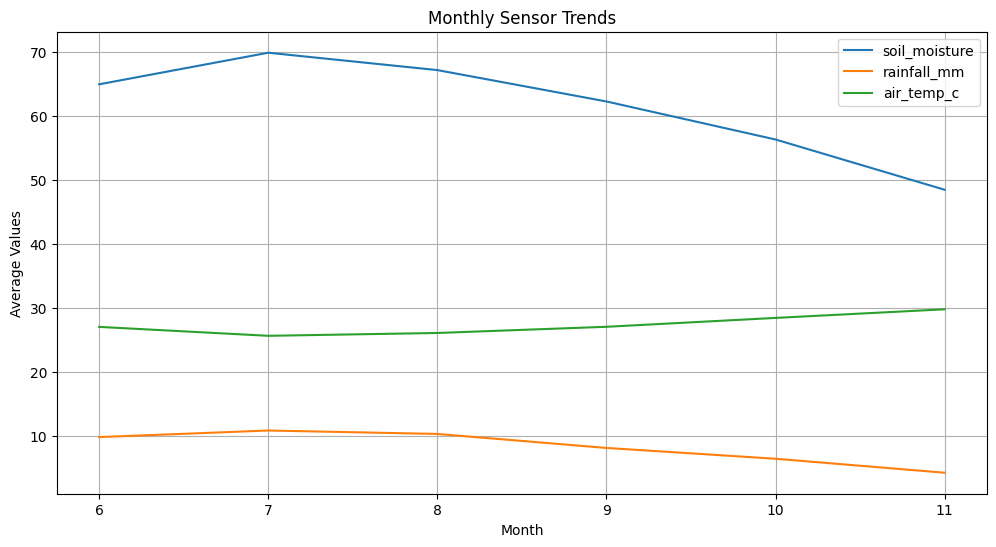

In [78]:
monthly_trends.plot(figsize=(12,6))

plt.title("Monthly Sensor Trends")
plt.xlabel("Month")
plt.ylabel("Average Values")

plt.grid(True)
plt.show()

**Insights**


Seasonal rainfall changes

Moisture fluctuations

Temperature rise patterns

**3. Correlation Heatmap per Crop**

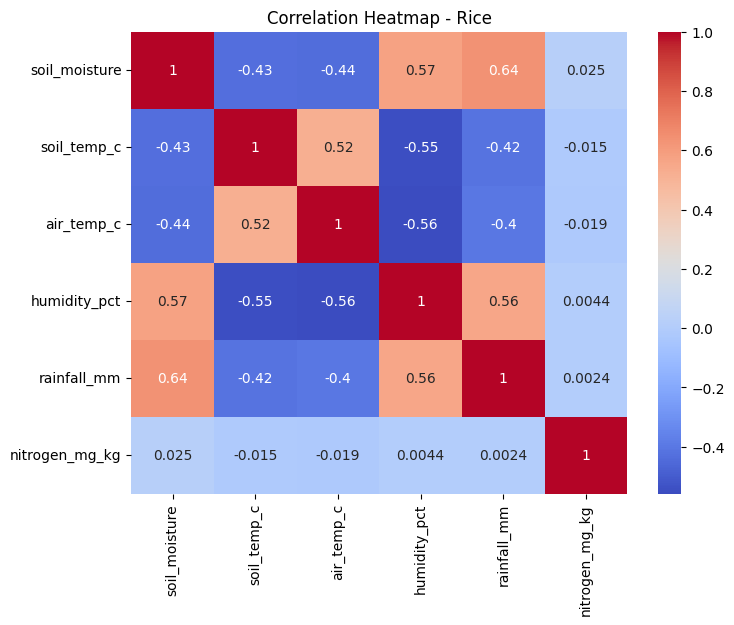

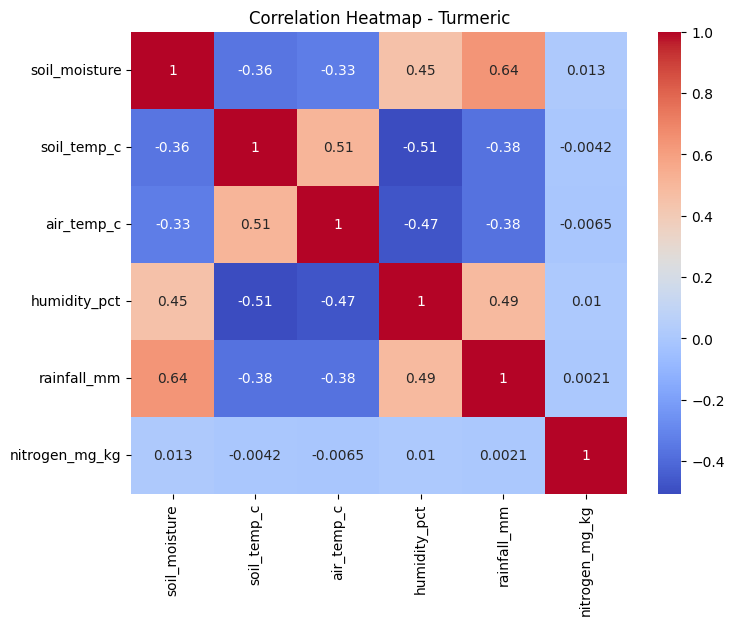

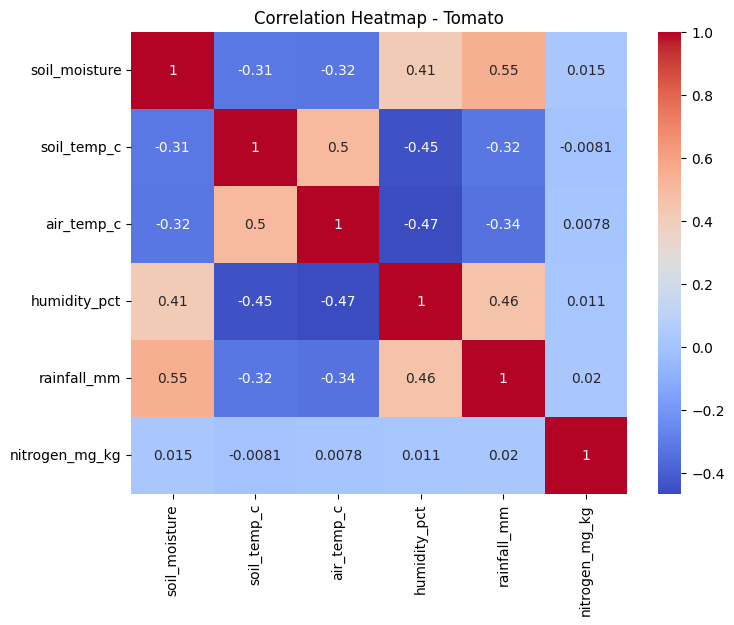

In [79]:
for crop in df['crop'].unique():

    crop_df = df[df['crop'] == crop]

    correlation = crop_df[[
        'soil_moisture',
        'soil_temp_c',
        'air_temp_c',
        'humidity_pct',
        'rainfall_mm',
        'nitrogen_mg_kg'
    ]].corr()

    plt.figure(figsize=(8,6))

    sns.heatmap(
        correlation,
        annot=True,
        cmap='coolwarm'
    )

    plt.title(f'Correlation Heatmap - {crop}')

    plt.show()



**Helps identify:**
Rainfall vs moisture relationship
Temperature vs humidity
Nutrient dependencies

**4. Anomaly Counts**

In [80]:
anomaly_counts = df['anomaly'].value_counts()

print(anomaly_counts)

anomaly
Normal                12602
Flood/Overwatering      175
Drought Stress          170
Heat Stress             160
Name: count, dtype: int64


**5.Boxplot**

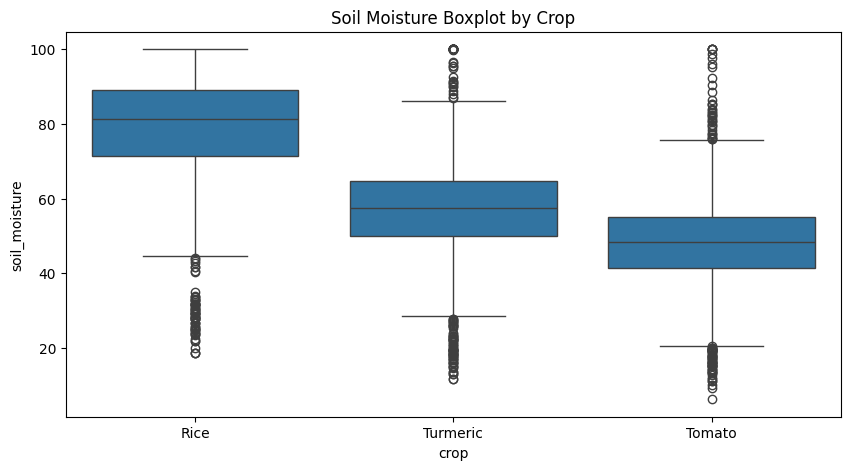

In [81]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='crop',
    y='soil_moisture',
    data=df
)

plt.title("Soil Moisture Boxplot by Crop")

plt.show()

**Rice (Thanjavur)**

Median 81% — highest among all 3 crops
IQR: 75–88% — very tight box — consistent high moisture maintained
Outliers below 40% — drought stress anomalies injected (Flood/Drought events)

**Insight: Paddy fields in Thanjavur maintain consistently high moisture — aligns with Cauvery delta irrigation system**


**Turmeric (Erode)**

Median 58% — moderate moisture
IQR: 53–65% — wider box than Rice — more variability
Outliers below 20% and above 95% — both drought and flood anomalies visible

**Insight: Turmeric needs moderate but consistent moisture — wide spread shows sensitivity to seasonal variation in Erode**


**Tomato (Coimbatore)**

Median 48% — lowest among all 3 crops
IQR: 35–75% — widest box — highest variability
Outliers both below 10% and above 95% — most anomaly-prone crop
**Insight: Tomato in Coimbatore faces highest irrigation stress — wide IQR confirms it triggers the most "Irrigate Now" alerts in the dataset**

**6. Hourly Diurnal Patterns**

In [82]:
hourly_patterns = df.groupby('hour')[[
    'soil_moisture',
    'air_temp_c',
    'humidity_pct'
]].mean()

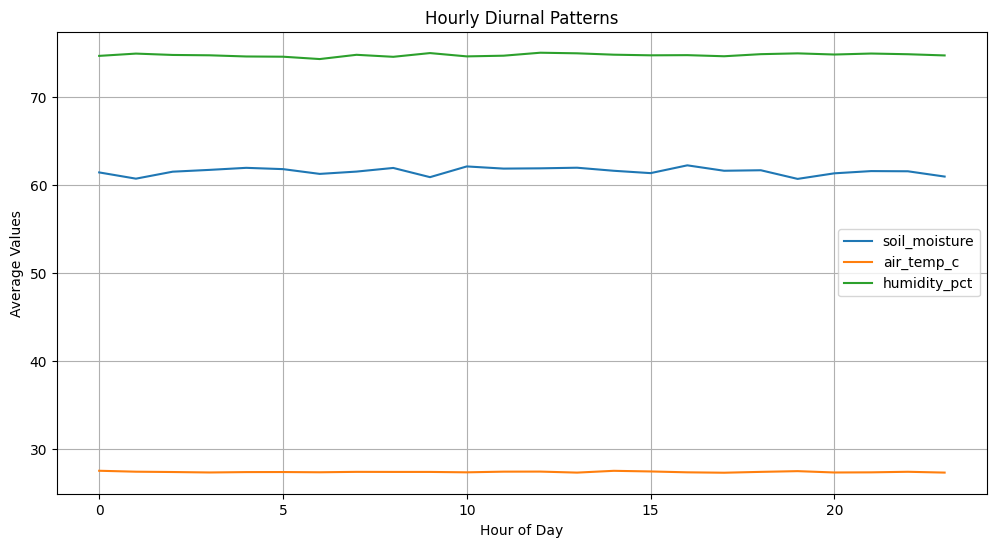

In [83]:
hourly_patterns.plot(figsize=(12,6))

plt.title("Hourly Diurnal Patterns")
plt.xlabel("Hour of Day")
plt.ylabel("Average Values")

plt.grid(True)

plt.show()

**"Hourly diurnal patterns show minimal variation across all 3 sensors throughout the day — soil moisture (62%), humidity (75%), and air temperature (28°C) remain stable.**

**This is a known limitation of simulated data — real IoT sensors would show clear diurnal cycles with temperature peaking at 13:00–15:00h and humidity inversely dropping."**



# **Data Splitting**

In [99]:

X = df[[
    'soil_moisture',
    'soil_temp_c',
    'air_temp_c',
    'humidity_pct',
    'rainfall_mm',
    'nitrogen_mg_kg'
]]

y = df['irrigation_needed']

print("\nFeature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



Feature Shape:
(13107, 6)

Target Shape:
(13107,)


# **Random Forest**

In [94]:
print("\n========== RANDOM FOREST ==========")

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=6,
    random_state=42,
    class_weight='balanced'
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", rf_accuracy)


========== RANDOM FOREST ==========
Random Forest Accuracy: 0.9565217391304348



**Parameters**

**n_estimators=50**


Number of decision trees built inside the forest

More trees = better accuracy but slower training

50 is a good starting point for medium datasets

Range typically used: 50–500


**max_depth=6**


How deep each decision tree can grow

Deeper = more complex = risk of overfitting

Shallow = simpler = risk of underfitting

6 means each tree makes maximum 6 split decisions

Like asking 6 yes/no questions to reach a conclusion


**random_state=42**


Sets a fixed seed for reproducibility

Ensures you get the same result every time you run

42 is just a convention — any number works

Without this — results change every run


**class_weight='balanced**


Handles class imbalance automatically

Our dataset has very few Irrigate Now rows (528) vs No Action (6400)

balanced tells the model to give more importance to minority class

Without this — model ignores Irrigate Now and accuracy looks artificially high

**Feature Importance**

In [96]:
importance = rf_model.feature_importances_
print("\nFeature Importance:")
for feature, score in zip(X.columns, importance):
    print(feature, ":", score)


Feature Importance:
soil_moisture : 0.5533846876134006
soil_temp_c : 0.043491430581189844
air_temp_c : 0.04124200462094679
humidity_pct : 0.0742815823889301
rainfall_mm : 0.21250557002093948
nitrogen_mg_kg : 0.07509472477459309


**A farmer checks soil moisture first → then looks at recent rainfall → then considers humidity before deciding to irrigate. Your model learned exactly this human decision process from data**

# **Support Vector Machine**

In [102]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale the data — mandatory for SVM
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Train SVM
svm_model = SVC(
    probability=True,
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train_sc, y_train)
svm_predictions = svm_model.predict(X_test_sc)
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.937070938215103


**Parameters**

**kernel='rbf'**

RBF = Radial Basis Function

Defines how SVM draws the boundary between classes

Think of it as the shape of the decision boundary

rbf draws curved boundaries — good for non-linear data like ours

Other options: linear, poly, sigmoid


**C=1.0**


Called the regularization parameter

Controls how strict the model is about misclassifications

High C → model tries to classify every point correctly → risk of overfitting

Low C → model allows some mistakes → better generalization

1.0 is a safe balanced default


**gamma='scale'**


Controls how far each training point influences the decision boundary

High gamma → each point influences only nearby points → complex boundary

Low gamma → each point influences farther points → smoother boundary

scale = automatically calculated as 1 / (n_features × variance) — safe default


**probability=True**


Enables the model to output probability scores per class

Without this — model only says "Monitor" or "Irrigate Now"

With this — model says "70% Monitor, 25% Irrigate Now, 5% No Action"

Required for LIME to work — LIME needs predict_proba


**random_state=42**


Same as RF — fixes seed for reproducibility

Ensures same results every run

**Permutation Importance**
Permutation importance works by shuffling one feature at a time and measuring how much accuracy drops — bigger drop = more important feature.


In [105]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm = permutation_importance(
    svm_model, X_test_sc, y_test,
    n_repeats=10,
    random_state=42
)

# Display results
importance_df = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("\nSVM Feature Importance (Permutation):")
for feat, score in importance_df.items():
    print(f"  {feat:<20} : {score:.4f}")


SVM Feature Importance (Permutation):
  soil_moisture        : 0.4894
  nitrogen_mg_kg       : 0.1162
  rainfall_mm          : 0.0249
  soil_temp_c          : 0.0135
  air_temp_c           : 0.0091
  humidity_pct         : 0.0047


**"Both Random Forest and SVM consistently identified soil moisture as the primary irrigation predictor.However RF weighted rainfall more heavily (21.2% vs 2.5%), suggesting RF better captures temporal moisture replenishment patterns — a key advantage for seasonal Tamil Nadu agriculture where monsoon rainfall directly drives soil water availability."**


# **Explainable AI using LIME**

Explains one prediction at a time — not the whole model

Zooms into a single data point — one field, one hour


Interpretable

Gives explanation in simple terms humans understand

Shows which features pushed prediction up or down

Model-agnostic

Works with ANY model — RF, SVM, XGBoost, Neural Network
Doesn't care how the model works internally


In [114]:
from sklearn.preprocessing import LabelEncoder

le_target   = LabelEncoder()
le_target.fit(df['irrigation_needed'])
CLASS_NAMES = le_target.classes_

print("Class Names:", CLASS_NAMES)

Class Names: [0 1 2]


In [115]:
CLASS_NAMES = {0: 'No Action', 1: 'Monitor', 2: 'Irrigate Now'}

=== LIME Explanation ===
True Label      : Monitor
Predicted Label : Monitor

Feature Contributions:
  -0.71 < soil_moisture <= -0.13      +0.3691  → pushes TO irrigate
  nitrogen_mg_kg <= -0.92             -0.1042  → pushes AWAY from irrigate
  rainfall_mm <= -0.68                -0.0858  → pushes AWAY from irrigate
  humidity_pct <= -0.71               +0.0519  → pushes TO irrigate
  air_temp_c <= -0.69                 -0.0321  → pushes AWAY from irrigate
  -0.72 < soil_temp_c <= -0.03        -0.0159  → pushes AWAY from irrigate

Actual Sensor Readings:
  soil_moisture        : 51.40
  soil_temp_c          : 23.96
  air_temp_c           : 24.55
  humidity_pct         : 65.09
  rainfall_mm          : 4.89
  nitrogen_mg_kg       : 119.52


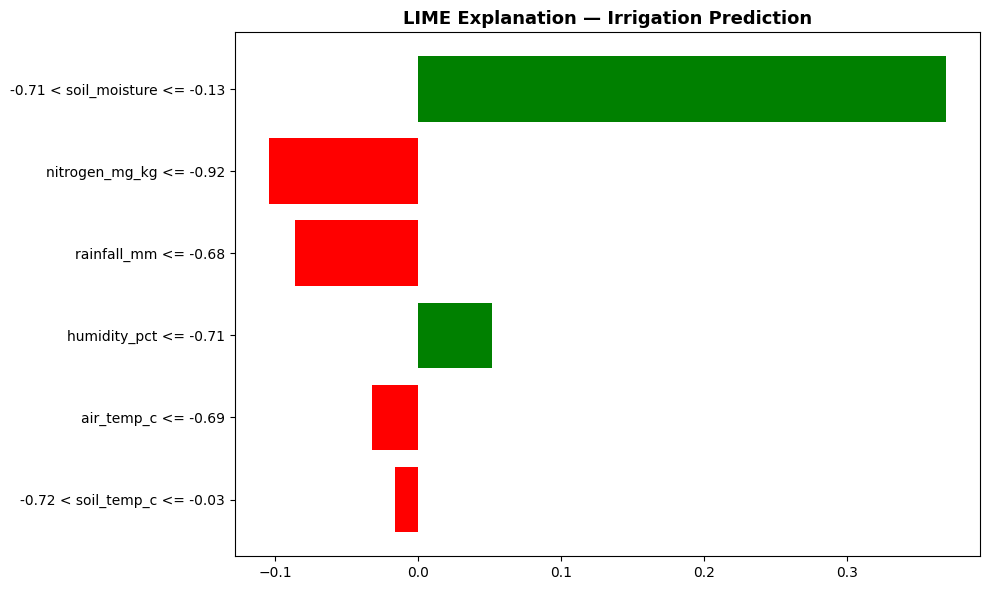

✅ Saved: lime_explanation.png


In [117]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_sc,
    feature_names = list(X.columns),
    class_names   = list(CLASS_NAMES),
    mode          = 'classification',
    random_state  = 42
)

sample_index = 0
sample       = X_test_sc[sample_index]

exp = explainer.explain_instance(
    data_row   = sample,
    predict_fn = svm_model.predict_proba,
    num_features = 6
)

print("=== LIME Explanation ===")
print(f"True Label      : {CLASS_NAMES[y_test.iloc[sample_index]]}")
print(f"Predicted Label : {CLASS_NAMES[svm_model.predict(sample.reshape(1,-1))[0]]}")
print(f"\nFeature Contributions:")
for feat, weight in exp.as_list():
    direction = "→ pushes TO irrigate" if weight > 0 else "→ pushes AWAY from irrigate"
    print(f"  {feat:<35} {weight:+.4f}  {direction}")

print(f"\nActual Sensor Readings:")
for col, val in X_test.iloc[sample_index].items():
    print(f"  {col:<20} : {val:.2f}")

fig = exp.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title("LIME Explanation — Irrigation Prediction", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('lime_explanation.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Saved: lime_explanation.png")

**"This field was classified as Monitor because soil moisture is low enough to raise concern (+0.37) but rainfall, nitrogen and temperature conditions are collectively pushing back (-0.22 total), balancing the decision at Monitor rather than escalating to Irrigate Now. The model is essentially saying — watch this field but don't irrigate yet."**

**"Your Thanjavur rice field soil is getting dry — keep an eye on it. Recent rainfall and stable temperatures suggest it can wait a little longer before irrigation is urgent."**